## Module 3: Statistical Inference for Linear Regression

### Step 0

Load the appropriate libraries and bring in the data. Note that we have to run a script to get the [California Housing dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) to match as it is in scikit-learn. We cannot pull it directly from scikit-learn since CodeGrade cannot access the internet.

In [1]:
# CodeGrade step0

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import os
import tarfile
import joblib # Import joblib directly
from sklearn.datasets._base import _pkl_filepath, get_data_home
import statsmodels.api as sm


archive_path = "cal_housing.tgz" # change the path if it's not in the current directory
data_home = get_data_home(data_home=None) # change data_home if you are not using ~/scikit_learn_data
if not os.path.exists(data_home):
    os.makedirs(data_home)
filepath = _pkl_filepath(data_home, 'cal_housing.pkz')

with tarfile.open(mode="r:gz", name=archive_path) as f:
    cal_housing = np.loadtxt(
        f.extractfile('CaliforniaHousing/cal_housing.data'),
        delimiter=',')
    # Columns are not in the same order compared to the previous
    # URL resource on lib.stat.cmu.edu
    columns_index = [8, 7, 2, 3, 4, 5, 6, 1, 0]
    cal_housing = cal_housing[:, columns_index]

    joblib.dump(cal_housing, filepath, compress=6) # Now using the directly imported joblib

# Load the dataset
california = fetch_california_housing(as_frame=True)
data = california.data
target = california.target

### Step 1

*   Create a copy of the data and call it `df`
*   Select the `X` variable to be `MedInc` and the `y` be `MedianHouseValue`
*   Add the constant term and call it `X_const`

Verify this by returning the shape of `X_const`

In [14]:
# CodeGrade step1

df = data.copy()

X = df[["MedInc"]]
y = target

X_const = sm.add_constant(X)

X_const.shape

(20640, 2)

### Step 2

*   fit the OLS model and call it `model`

Then return the rounded model $r^2$ value to four decimal places.

In [15]:
# CodeGrade step2

model = sm.OLS(y, X_const).fit()

round(model.rsquared, 4)


np.float64(0.4734)

Print the model summary


In [18]:
# Display the summary

model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:51:29   Log-Likelihood:                -25623.
No. Observations:               20640   AIC:                         5.125e+04
Df Residuals:                   20638   BIC:                         5.127e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4509      0.013     34.082      0.0

### Step 3

Extract the slope and the related statistics for `MedInc`, calling them, respetively, `slope`, `std_error`, `t_statistic`, and `p_value`.

Return the following (do not round) to verify: `slope, std_error, t_statistic, p_value`.


In [19]:
# CodeGrade step3


slope = model.params["MedInc"]
std_error = model.bse["MedInc"]
t_statistic = model.tvalues["MedInc"]
p_value = model.pvalues["MedInc"]

slope, std_error, t_statistic, p_value

(np.float64(0.41793849201896155),
 np.float64(0.0030680575388678296),
 np.float64(136.2225077998989),
 np.float64(0.0))

### Step 4

Calculuate the confidence interval of `MedInc` at a 95% level of confidence, and call this `conf_int`.

Return the confidence interval rounded to four decimals places.

In [20]:
# CodeGrade step4
conf_int = model.conf_int().loc["MedInc"]

conf_int.round(4)

0    0.4119
1    0.4240
Name: MedInc, dtype: float64

### Step 5

Find the model predictions, call them `y_pred`.

Return `y_pred.shape` to verify.

In [21]:
# CodeGrade step5
y_pred = model.predict(X_const)

y_pred.shape

(20640,)

Plot the scatterplot with the regression line.

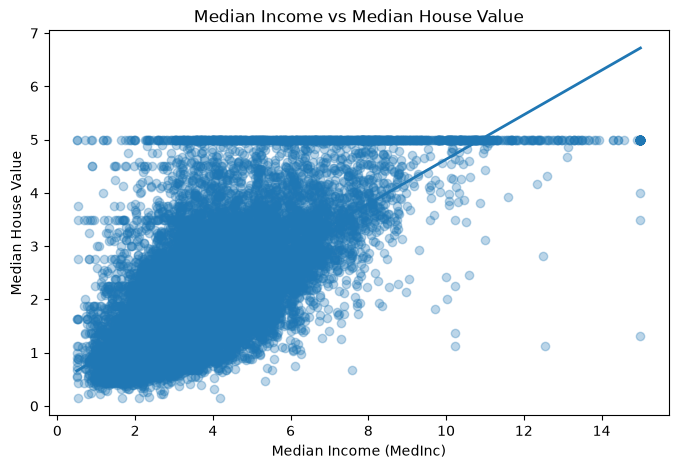

In [22]:
# Plot the scatterplot with regression line


y_pred = model.predict(X_const)

plt.figure(figsize=(8, 5))
plt.scatter(X["MedInc"], y, alpha=0.3)

# Sort values so the regression line is drawn correctly
sorted_indices = X["MedInc"].argsort()
plt.plot(X["MedInc"].iloc[sorted_indices], y_pred.iloc[sorted_indices], linewidth=2)
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()